<a href="https://colab.research.google.com/github/HafizaNoorUlSaba/langgraph/blob/Langgraph_state/LangGraph_State_Machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Install Libraries***

In [8]:
!pip install langchain langgraph typing langchain-google-genai langchain-groq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for typing: filename=typing-3.7.4.3-py3-none-any.whl size=26304 sha256=221837587bdf70fd637c09793015f2a9a3d6edc8f0ac0bd5d96e422d6f8dbc40
  Stored in directory: /root/.cache/pip/wheels/12/98/52/2bffe242a9a487f00886e43b8ed8dac46456702e11a0d6abef
Successfully built typing


***Import Libraries***

In [1]:

from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv


In [2]:
import os
from google.colab import userdata

# Retrieve the API key from Colab secrets and set it as an environment variable
# Ensure you have a secret named 'GROQ_API_KEY' in Colab secrets.
groq_api_key_from_secrets = userdata.get('Groq_Api_Key')

if groq_api_key_from_secrets:
    os.environ['GROQ_API_KEY'] = groq_api_key_from_secrets
    print("GROQ_API_KEY loaded from Colab secrets.")
else:
    print("Warning: GROQ_API_KEY secret not found in Colab secrets. Please ensure it's set correctly.")

GROQ_API_KEY loaded from Colab secrets.


***Define the State***

In [3]:
class ChatState(TypedDict):
    question: str
    answer: str

***Load the LLM***

In [5]:
llm = ChatGroq(
    groq_api_key=os.getenv("Groq_Api_Key"),
    model_name="openai/gpt-oss-120b" # Corrected to a supported Groq model
)
model = llm

In [6]:
def answer_question(state: ChatState):

    response = llm.invoke(state["question"])

    return {
        "answer": response.content
    }

***Build the graph***

In [7]:
graph = StateGraph(ChatState)

In [8]:
graph.add_node("answer", answer_question)

In [9]:
graph.add_edge(START, "answer")

graph.add_edge("answer", END)

In [10]:
app = graph.compile()

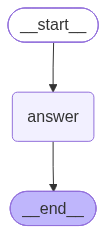

In [15]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [11]:
result = app.invoke({
    "question": "Explain LangGraph in simple words."
})

print(result["answer"])

**LangGraph in a nutshell**

Imagine you want to build a chatbot or any AI‑powered workflow, but instead of writing one long script that does everything, you break the job into smaller, reusable pieces (like Lego blocks) and tell them how they should talk to each other.  

LangGraph is a Python library that lets you do exactly that: it lets you **draw a graph** (nodes + edges) where each node is a piece of logic that runs an LLM (or any other code) and each edge decides what comes next based on the output.

### The key ideas, explained simply

| Concept | What it means in plain language |
|---------|-----------------------------------|
| **Node** | A single step in the workflow. It could be “ask the user a question”, “call the OpenAI API”, “run a calculator”, or “store something in memory”. |
| **Edge** | The rule that decides where to go after a node finishes. It looks at the node’s result (or some stored state) and says “go to node A if the answer is yes, otherwise go to node B”. |
|

In [16]:
def formatter(state: ChatState):

    formatted = (
        "===== AI Answer =====\n"
        f"{state['answer']}\n"
        "====================="
    )

    return {
        "answer": formatted
    }

In [17]:
graph = StateGraph(ChatState)

graph.add_node("answer", answer_question)

graph.add_node("format", formatter)

graph.add_edge(START, "answer")

graph.add_edge("answer", "format")

graph.add_edge("format", END)

app = graph.compile()

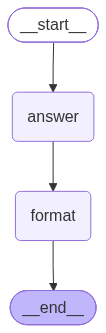

In [18]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [19]:
result = app.invoke({
    "question": "What is an AI Agent?"
})

print(result["answer"])

===== AI Answer =====
**AI Agent – a concise definition**

An **AI agent** is a software entity that **perceives its environment**, **processes that information**, and **takes actions** in order to achieve one or more **goals**.  In other words, it is a “sense‑think‑act” loop powered by artificial‑intelligence techniques.

| Component | What it means for an AI agent |
|-----------|------------------------------|
| **Perception (sensing)** | Receives data from the world (e.g., camera frames, text, API responses, sensor readings). |
| **Decision‑making (thinking)** | Uses models, reasoning, planning, or learning to decide what to do next. This is where the “AI” part lives—machine‑learning classifiers, reinforcement‑learning policies, knowledge graphs, symbolic planners, etc. |
| **Action (actuation)** | Sends commands back to the environment (e.g., moving a robot, sending a message, updating a database, triggering a UI change). |
| **Goal/Utility** | A measurable objective that the agent